## Lab # 02: Simple and Multiple Linear Regression


### **Student Information**
- **Name**: Abdul Hayy Khan
- **Roll No**: 24F-AI-051

#### Task 1: Simple Linear Regression

- Load dataset: Use the Diabetes dataset from sklearn.datasets. Select one feature (bmi) to predict the target (disease progression).
- Perform Exploratory Data Analysis (EDA):
    - Plot scatter plot of BMI vs. Disease Progression.
    - Check correlation.
- Implement Simple Linear Regression using sklearn.linear_model.LinearRegression:
    - Split data into training and testing sets.
    - Fit the model and predict disease progression.
    - Plot the regression line on the scatter plot.
- Evaluate the model using:
    - Mean Squared Error (MSE)
    - R² score

Does BMI alone explain most of the variation in disease progression? How does R² help explain this?


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

# Load the Diabetes dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

In [2]:
# Select BMI as the predictor and disease progression as the target
X_bmi = df[['bmi']]
y = df['target']

In [3]:
# Exploratory Data Analysis: correlation
correlation = X_bmi['bmi'].corr(y)
print(f"Correlation between BMI and disease progression: {correlation:.4f}")

Correlation between BMI and disease progression: 0.5865


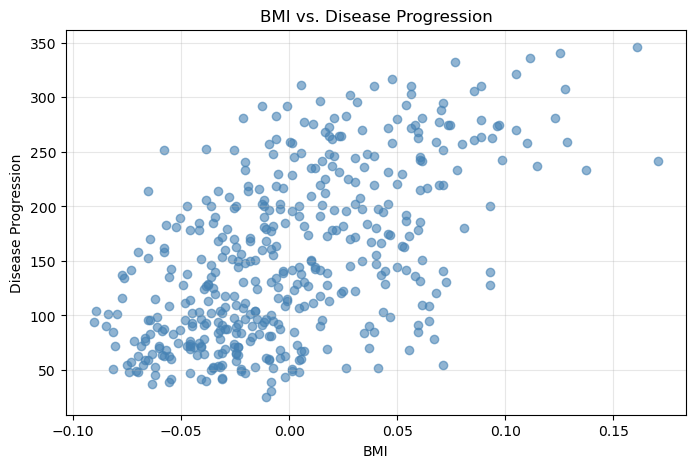

In [4]:
# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(X_bmi['bmi'], y, alpha=0.6, color='steelblue')
plt.title("BMI vs. Disease Progression")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.grid(alpha=0.3)
plt.show()

In [5]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_bmi, y, test_size=0.2, random_state=42
)

In [6]:
# Train the simple linear regression model
slr_model = LinearRegression()
slr_model.fit(X_train, y_train)

LinearRegression()

In [7]:
# Predictions
y_pred_slr = slr_model.predict(X_test)

In [8]:
# Evaluation metrics
mse_slr = mean_squared_error(y_test, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr = r2_score(y_test, y_pred_slr)
print(f"Mean Squared Error (MSE): {mse_slr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_slr:.2f}")
print(f"R-squared Score (R²): {r2_slr:.4f}")

Mean Squared Error (MSE): 4061.83
Root Mean Squared Error (RMSE): 63.73
R-squared Score (R²): 0.2334


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


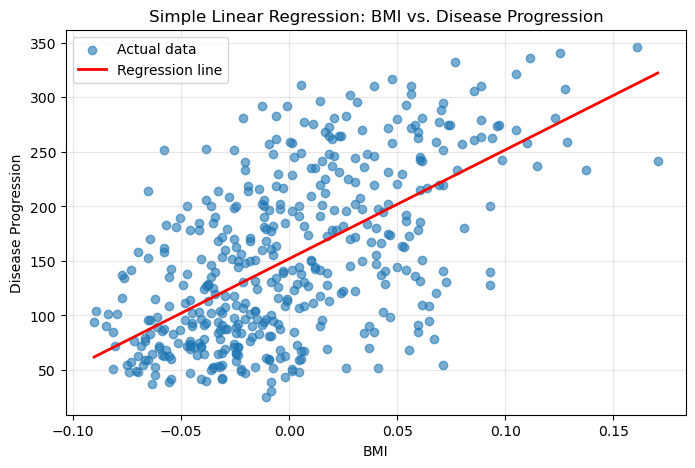

In [9]:
# Plot regression line
x_line = np.linspace(X_bmi['bmi'].min(), X_bmi['bmi'].max(), 100).reshape(-1, 1)
y_line = slr_model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_bmi['bmi'], y, alpha=0.6, label="Actual data")
plt.plot(x_line, y_line, color='red', linewidth=2, label="Regression line")
plt.title("Simple Linear Regression: BMI vs. Disease Progression")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
print(
    f"BMI alone explains approximately {r2_slr * 100:.2f}% of the variation "
    "in disease progression. The R² score measures the proportion of target "
    "variation explained by the model, so BMI does not explain most of the variation."
)

BMI alone explains approximately 23.34% of the variation in disease progression. The R² score measures the proportion of target variation explained by the model, so BMI does not explain most of the variation.


#### Task 2: Multivariate Linear Regression

- Load dataset: Use the same Diabetes dataset, but include all 10 features to predict disease progression.
- Perform EDA:
    - Generate a correlation heatmap between features and the target.
    - Create pair plots for selected features vs. target.
- Implement Multivariate Linear Regression:
    - Use all independent variables to predict the target.
    - Fit and predict using the model.
- Compare actual vs. predicted values using:
    - Scatter plot (predicted vs. actual).
    - Residual plot.
- Evaluate model performance with:
    - MSE
    - RMSE
    - R² score

Which independent variable contributes the most to predicting disease progression? 

In [11]:
import seaborn as sns

# Use all 10 features
feature_names = diabetes.feature_names
X = df[feature_names]
y_mlr = df["target"]

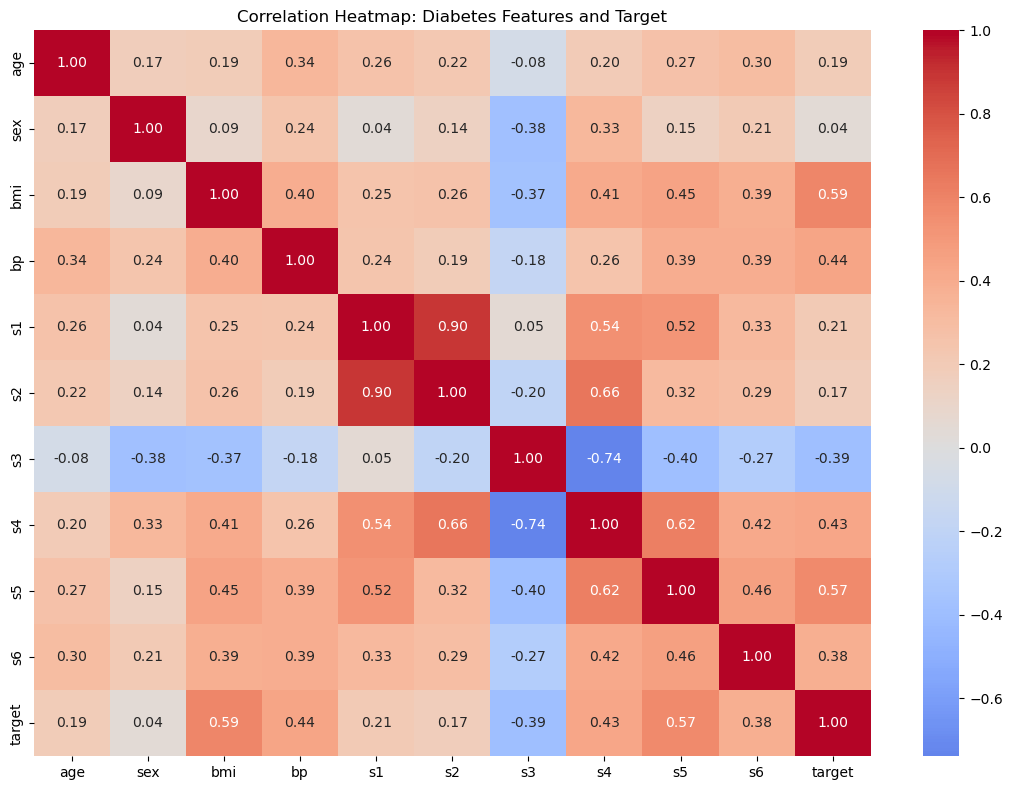

In [12]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(
    df[feature_names + ["target"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)
plt.title("Correlation Heatmap: Diabetes Features and Target")
plt.tight_layout()
plt.show()


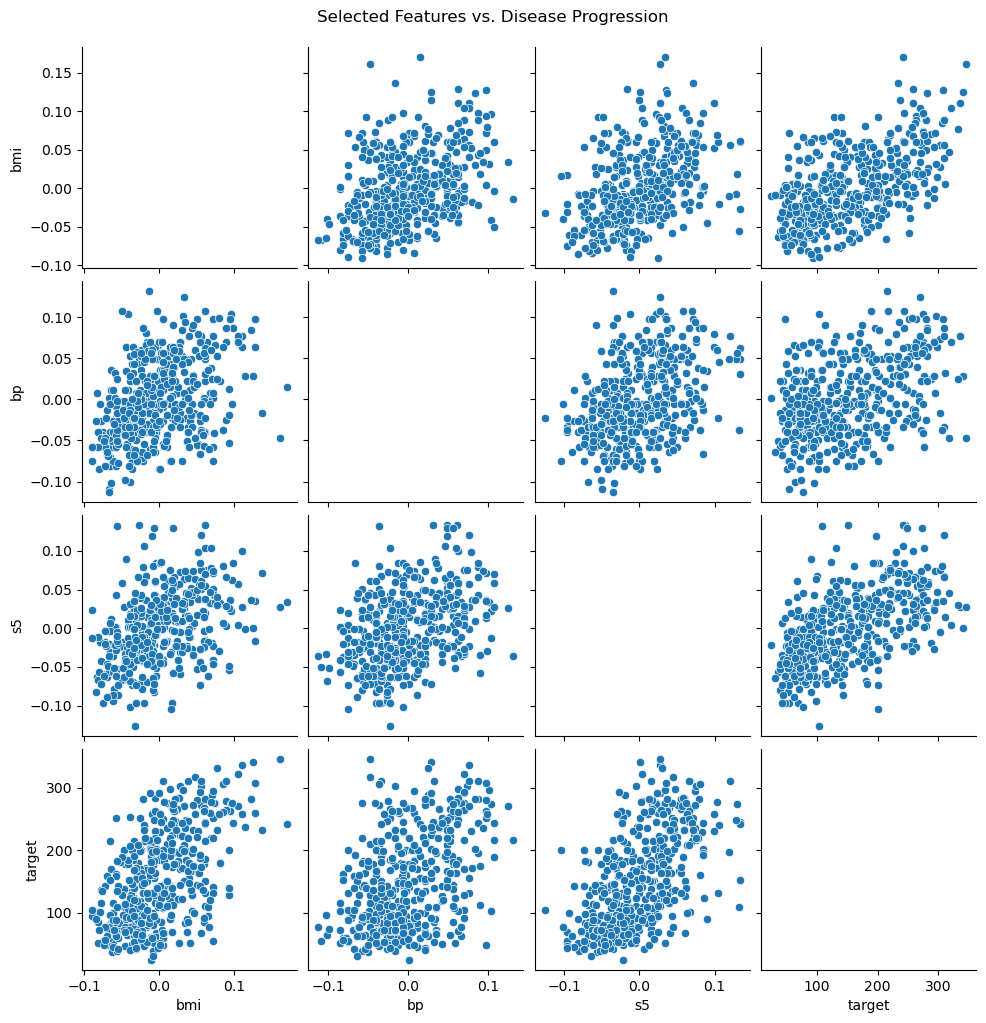

In [13]:
# Pair plots for selected features
selected_features = ["bmi", "bp", "s5", "target"]
sns.pairplot(df[selected_features], diag_kind=" hist")
plt.suptitle("Selected Features vs. Disease Progression", y=1.02)
plt.show()

In [14]:
# Split the data
X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    X, y_mlr, test_size=0.2, random_state=42
)

In [15]:
# Train the multivariate linear regression model
mlr_model = LinearRegression()
mlr_model.fit(X_train_mlr, y_train_mlr)

LinearRegression()

In [16]:
# Predictions
y_pred_mlr = mlr_model.predict(X_test_mlr)
residuals_mlr = y_test_mlr - y_pred_mlr

In [17]:
# Evaluation metrics
mse_mlr = mean_squared_error(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr = r2_score(y_test_mlr, y_pred_mlr)
print(f"Mean Squared Error (MSE): {mse_mlr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_mlr:.2f}")
print(f"R-squared Score (R²): {r2_mlr:.4f}")

Mean Squared Error (MSE): 2900.19
Root Mean Squared Error (RMSE): 53.85
R-squared Score (R²): 0.4526


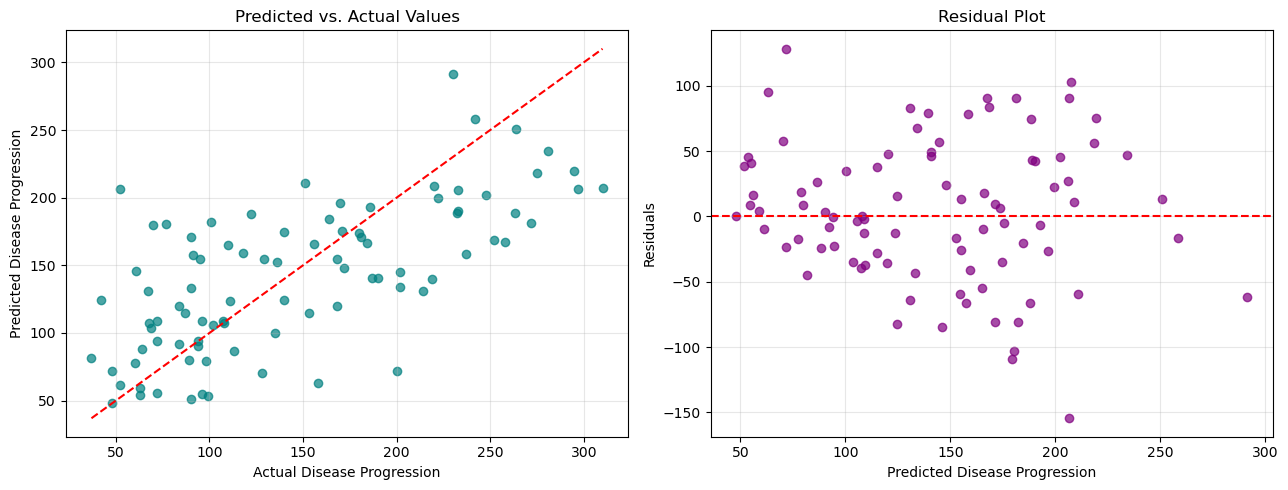

In [18]:
# Predicted vs. actual and residual plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_mlr, y_pred_mlr, alpha=0.7, color="teal")
axes[0].plot(
    [y_test_mlr.min(), y_test_mlr.max()],
    [y_test_mlr.min(), y_test_mlr.max()],
    "r--"
)
axes[0].set_title("Predicted vs. Actual Values")
axes[0].set_xlabel("Actual Disease Progression")
axes[0].set_ylabel("Predicted Disease Progression")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_pred_mlr, residuals_mlr, alpha=0.7, color="purple")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted Disease Progression")
axes[1].set_ylabel("Residuals")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Feature coefficient analysis
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": mlr_model.coef_,
    "Absolute Coefficient": np.abs(mlr_model.coef_)
}).sort_values("Absolute Coefficient", ascending=False)

print("\nFeature Contributions:")
display(coefficient_df)

most_influential_feature = coefficient_df.iloc[0]["Feature"]
print(
    f"The independent variable with the largest contribution based on the "
    f"absolute regression coefficient is: {most_influential_feature}"
)


Feature Contributions:


,Feature,Coefficient,Absolute Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


The independent variable with the largest contribution based on the absolute regression coefficient is: s1


#### Task 3: Experimentation & Model Comparison

- Compare performance of simple vs. multivariate regression in terms of evaluation metrics.

In [20]:
# Compare model performance
comparison_df = pd.DataFrame({
    "Model": [
        "Simple Linear Regression (BMI only)",
        "Multivariate Linear Regression (All 10 Features)"
    ],
    "MSE": [mse_slr, mse_mlr],
    "RMSE": [rmse_slr, rmse_mlr],
    "R²": [r2_slr, r2_mlr],
    "Variance Explained (%)": [r2_slr * 100, r2_mlr * 100]
})

display(comparison_df.style.format({
    "MSE": "{:.2f}",
    "RMSE": "{:.2f}",
    "R²": "{:.4f}",
    "Variance Explained (%)": "{:.2f}%"
}))

print(
    f"Multivariate regression performs better: RMSE decreases from "
    f"{rmse_slr:.2f} to {rmse_mlr:.2f}, while R² increases from "
    f"{r2_slr:.4f} to {r2_mlr:.4f}."
)

,Model,MSE,RMSE,R²,Variance Explained (%)
0,Simple Linear Regression (BMI only),4061.83,63.73,0.2334,23.34%
1,Multivariate Linear Regression (All 10 Features),2900.19,53.85,0.4526,45.26%


Multivariate regression performs better: RMSE decreases from 63.73 to 53.85, while R² increases from 0.2334 to 0.4526.
